In [6]:
from collections import deque

import networkx as nx
from networkx.drawing.nx_pydot import graphviz_layout

In [10]:
graph = dict()
graph["A"] = ["B", "S"]
graph["B"] = ["A"]
graph["S"] = ["A", "G", "C"]
graph["D"] = ["C"]
graph["G"] = ["S", "F", "H"]
graph["H"] = ["G", "E"]
graph["E"] = ["C", "H"]
graph["F"] = ["C", "G"]
graph["C"] = ["D", "S", "E", "F"]

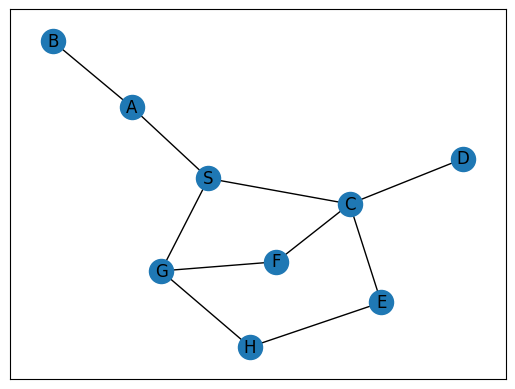

In [14]:
g = nx.Graph()
for k, v in graph.items():
    g.add_node(k)
    for _v in v:
        if _v not in g.nodes():
            g.add_node(_v)
        g.add_edge(k, _v)

pos = graphviz_layout(g)
nx.draw_networkx(g, labels={n: str(n) for n in g.nodes()}, pos=pos)

In [2]:
def depth_first_search(graph, root):
    visited_vertices = list()
    graph_stack = list()
    graph_stack.append(root)
    node = root
    while graph_stack:
        if node not in visited_vertices:
            visited_vertices.append(node)
        adj_nodes = graph[node]
        if set(adj_nodes).issubset(set(visited_vertices)):
            graph_stack.pop()
            if len(graph_stack) > 0:
                node = graph_stack[-1]
            continue
        else:
            remaining_elements = set(adj_nodes).difference(set(visited_vertices))

        first_adj_node = sorted(remaining_elements)[0]
        graph_stack.append(first_adj_node)
        node = first_adj_node
    return visited_vertices


print(depth_first_search(graph, "A"))

['A', 'B', 'S', 'C', 'D', 'E', 'H', 'G', 'F']


In [4]:
def breadth_first_search(graph, root):
    visited_vertices = list()
    graph_queue = deque([root])
    visited_vertices.append(root)
    node = root

    while len(graph_queue) > 0:
        node = graph_queue.popleft()
        adj_nodes = graph[node]

        remaining_elements = set(adj_nodes).difference(set(visited_vertices))
        if len(remaining_elements) > 0:
            for elem in sorted(remaining_elements):
                visited_vertices.append(elem)
                graph_queue.append(elem)

    return visited_vertices


print(breadth_first_search(graph, "A"))

['A', 'B', 'S', 'C', 'G', 'D', 'E', 'F', 'H']
